In [3]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

In [5]:
strategy = tf.distribute.MirroredStrategy()
print("GPUs:", strategy.num_replicas_in_sync)

AUTO = tf.data.AUTOTUNE
BATCH_SIZE = 256
IMG_SIZE = (224,224)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs: 2


In [11]:
TRAIN_DIR = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/train_balanced'
VAL_DIR = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/val_balanced'
TEST_DIR = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/test_balanced'

MODEL_DIR = '/kaggle/input/models/varunsiddharthkaza/retinal-oct-models/keras/default/1'

MODEL_PATHS = {
    "VGG16": '/kaggle/input/models/varunsiddharthkaza/retinal-oct-models/keras/default/1/VGG16_finetuned.keras',
    "ResNet50": '/kaggle/input/models/varunsiddharthkaza/retinal-oct-models/keras/default/1/ResNet50_finetuned.keras',
    "DenseNet121": '/kaggle/input/models/varunsiddharthkaza/retinal-oct-models/keras/default/1/DenseNet121_finetuned.keras',
    "Xception": '/kaggle/input/models/varunsiddharthkaza/retinal-oct-models/keras/default/1/Xception_finetuned.keras',
    "EfficientNetB3": '/kaggle/input/models/varunsiddharthkaza/retinal-oct-models/keras/default/1/EfficientNetB3_finetuned.keras'
}

In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names
test_ds = test_ds.prefetch(AUTO)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

Found 12650 files belonging to 4 classes.


In [8]:
# FLOPs Function

def get_flops(model):

    concrete_func = tf.function(
        lambda x: model(x)
    ).get_concrete_function(
        tf.TensorSpec([1,224,224,3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd="op",
            options=opts
        )

    return flops.total_float_ops / 1e9

In [9]:
# Inference Benchmark

def benchmark_inference(model, dataset):
    start = time.perf_counter()
    preds = model.predict(dataset, verbose=0)
    end = time.perf_counter()
    total_images = len(preds)
    total_time = end - start
    ms_per_image = (total_time / total_images) * 1000
    return preds, ms_per_image

In [14]:
# Main Evaluation Loop

results = []

for model_name, model_path in MODEL_PATHS.items():
    print(f"\nEvaluating {model_name}")

    with strategy.scope():
        model = tf.keras.models.load_model(model_path)

    params = model.count_params()
    start = time.perf_counter()
    preds = model.predict(test_ds, verbose=0)
    end = time.perf_counter()

    inference_time_ms = ((end - start) / len(preds)) * 1000
    y_pred = np.argmax(preds, axis=1)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Params_M": params / 1e6,
        "Inference_ms": inference_time_ms
    })
    tf.keras.backend.clear_session()


Evaluating VGG16


I0000 00:00:1781765394.567071     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781765394.569152     129 cuda_dnn.cc:529] Loaded cuDNN version 91002



Evaluating ResNet50

Evaluating DenseNet121

Evaluating Xception

Evaluating EfficientNetB3


In [31]:
comparison_df = pd.DataFrame(results)
comparison_df["Accuracy"] = comparison_df["Accuracy"].round(4)
comparison_df["Macro_F1"] = comparison_df["Macro_F1"].round(4)
comparison_df["Params_M"] = comparison_df["Params_M"].round(2)
comparison_df["Inference_ms"] = comparison_df["Inference_ms"].round(3)
comparison_df["GFLOPs"] = [15.33, 4.10, 5.74, 2.96, 1.22]

comparison_df = comparison_df[["Model", "Accuracy", "Macro_F1", "Params_M", "GFLOPs", "Inference_ms"]]
comparison_df

,Model,Accuracy,Macro_F1,Params_M,GFLOPs,Inference_ms
0,VGG16,0.9711,0.9589,14.85,15.33,3.898
1,ResNet50,0.9425,0.9146,24.11,4.10,3.071
2,DenseNet121,0.9128,0.8620,7.30,5.74,3.703
3,Xception,0.9479,0.9251,21.39,2.96,3.935
4,EfficientNetB3,0.9341,0.9008,11.18,1.22,3.405


In [32]:
comparison_df.to_csv("architecture_comparison.csv", index=False)

In [33]:
plot_df = comparison_df.sort_values("GFLOPs")

pareto_models = []
best_acc = -1

for _, row in plot_df.iterrows():
    if row["Accuracy"] > best_acc:
        pareto_models.append(row["Model"])
        best_acc = row["Accuracy"]
comparison_df["Pareto"] = comparison_df["Model"].isin(pareto_models)

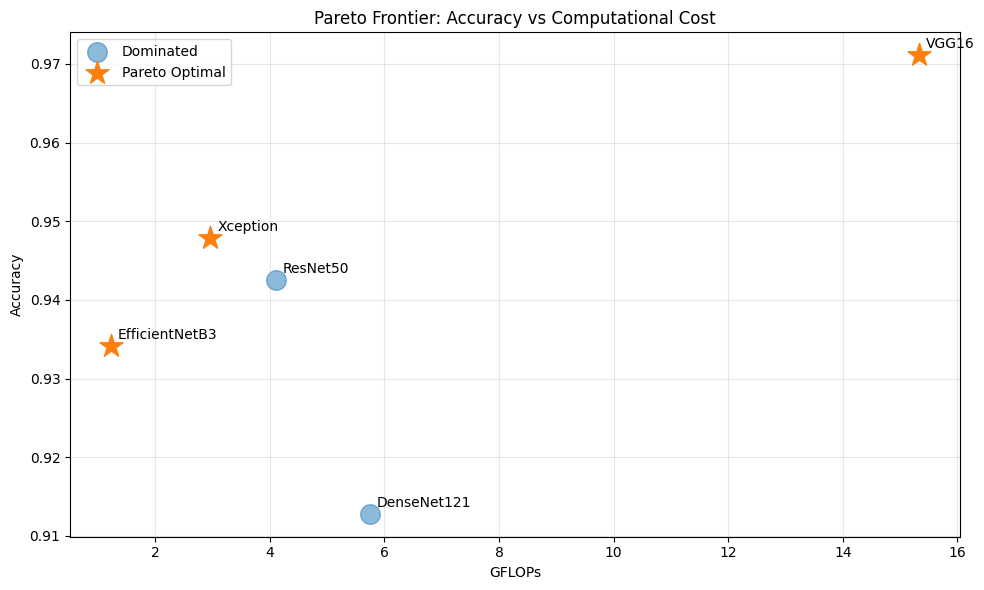

In [34]:
plt.figure(figsize=(10,6))

non_pareto = comparison_df[~comparison_df["Pareto"]]
pareto = comparison_df[comparison_df["Pareto"]]

plt.scatter(
    non_pareto["GFLOPs"],
    non_pareto["Accuracy"],
    s=200,
    alpha=0.5,
    label="Dominated"
)

plt.scatter(
    pareto["GFLOPs"],
    pareto["Accuracy"],
    s=300,
    marker="*",
    label="Pareto Optimal"
)

for _, row in comparison_df.iterrows():

    plt.annotate(
        row["Model"],
        (row["GFLOPs"], row["Accuracy"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("GFLOPs")
plt.ylabel("Accuracy")
plt.title("Pareto Frontier: Accuracy vs Computational Cost")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Accuracy-vs-Computational-Cost-Pareto-Frontier.png', dpi=600)
plt.show()

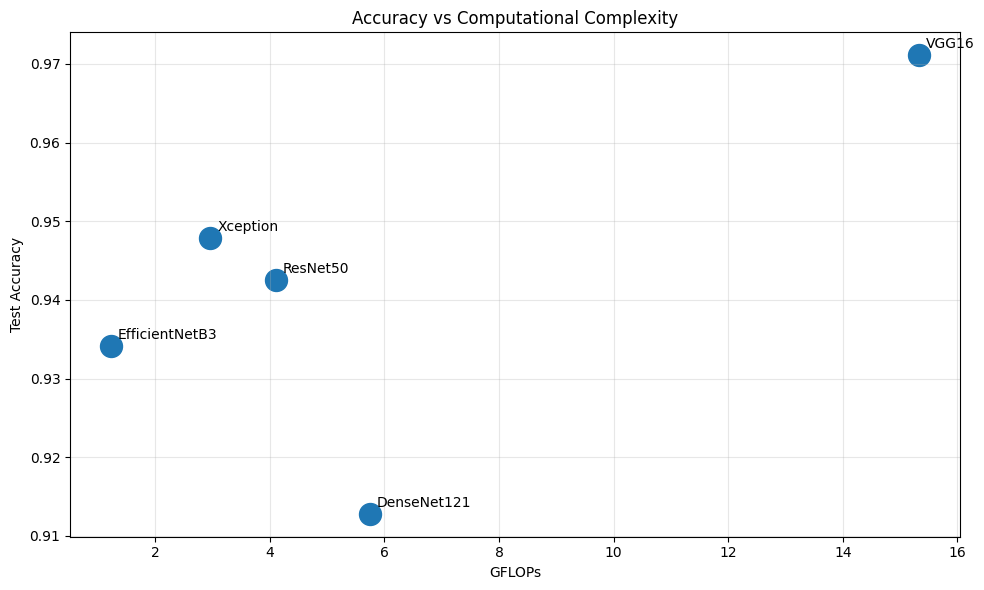

In [35]:
import matplotlib.pyplot as plt

plot_df = comparison_df.sort_values("GFLOPs")
plt.figure(figsize=(10,6))

plt.scatter(
    plot_df["GFLOPs"],
    plot_df["Accuracy"],
    s=250
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["GFLOPs"], row["Accuracy"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("GFLOPs")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Computational Complexity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Accuracy-vs-Computational-Complexity.png', dpi=600)
plt.show()